In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [4]:
CSV_PATH = "dataset_as03.csv"   

df = pd.read_csv(CSV_PATH)

# Replace SQL-style missing marker "\N" with NaN
df = df.replace(r"\N", np.nan)

# Parse timestamp (the assignment uses `name` as timestamp, format yyyymmddhhmm) :contentReference[oaicite:1]{index=1}
df["time"] = pd.to_datetime(df["name"].astype(str), format="%Y%m%d%H%M", errors="coerce")
df = df.sort_values("time").reset_index(drop=True)

In [5]:
# Convert all non-time columns to numeric where possible
for c in df.columns:
    if c not in ["name", "time"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")

print("Rows:", len(df))
print("Time range:", df["time"].min(), "→", df["time"].max())

Rows: 12084
Time range: 2015-09-07 11:00:00 → 2015-11-30 23:50:00


In [6]:
def plot_timeseries_group(df_plot: pd.DataFrame, cols: list[str], title: str, ylabel: str):
   
    plt.figure(figsize=(12, 4))
    labels = ["Mean", "Min", "Max", "Stdv"]
    for col, lab in zip(cols, labels):
        if col in df_plot.columns:
            plt.plot(df_plot["time"], df_plot[col], label=f"{lab} ({col})", linewidth=0.9)

    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel(ylabel)
    plt.grid(True, alpha=0.3)
    plt.legend(ncol=2, fontsize=8)
    plt.tight_layout()
    plt.show()


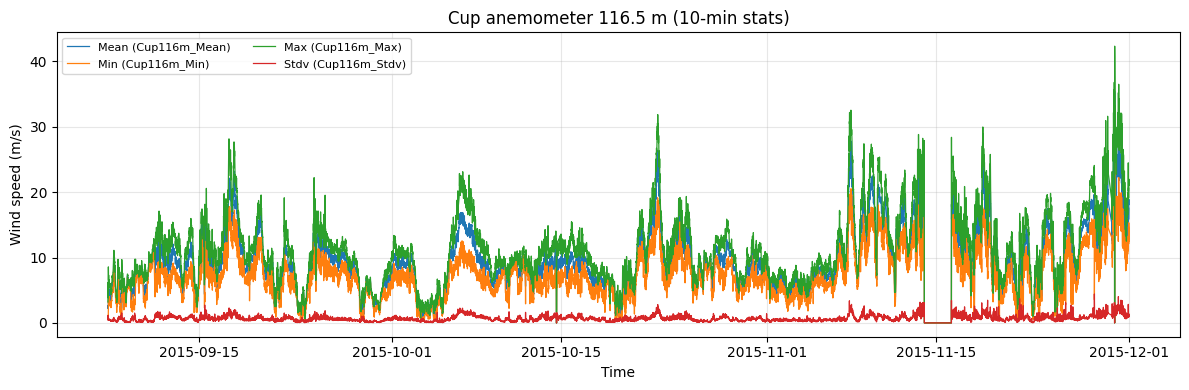

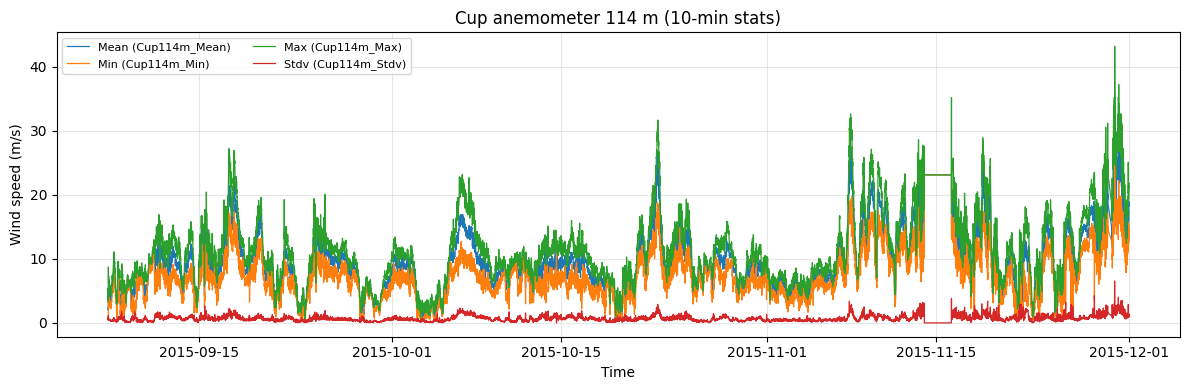

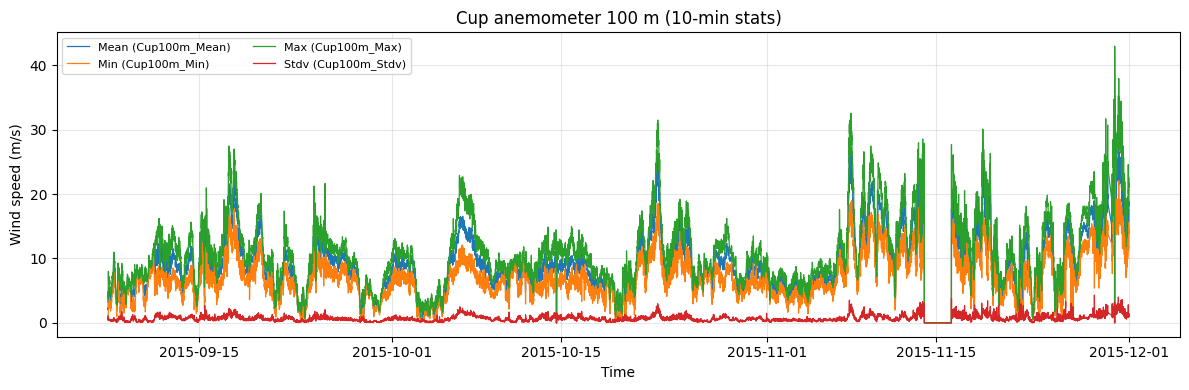

In [7]:
plot_timeseries_group(
    df,
    ["Cup116m_Mean", "Cup116m_Min", "Cup116m_Max", "Cup116m_Stdv"],
    "Cup anemometer 116.5 m (10-min stats)",
    "Wind speed (m/s)",
)
plot_timeseries_group(
    df,
    ["Cup114m_Mean", "Cup114m_Min", "Cup114m_Max", "Cup114m_Stdv"],
    "Cup anemometer 114 m (10-min stats)",
    "Wind speed (m/s)",
)
plot_timeseries_group(
    df,
    ["Cup100m_Mean", "Cup100m_Min", "Cup100m_Max", "Cup100m_Stdv"],
    "Cup anemometer 100 m (10-min stats)",
    "Wind speed (m/s)",
)

In [31]:
# ----------------------------
# QC CONDITIONS + APPLY (set NaN)
# ----------------------------

def minmax_mean_std_mask(df, prefix):
    """Generic consistency + dropout checks for *_Mean/_Min/_Max/_Stdv."""
    m = pd.Series(False, index=df.index)

    mu = f"{prefix}_Mean"
    mn = f"{prefix}_Min"
    mx = f"{prefix}_Max"
    sd = f"{prefix}_Stdv"

    # min/max consistency
    if mn in df.columns and mx in df.columns:
        m |= (df[mn] > df[mx])

    # mean must lie between min and max (if available)
    if mu in df.columns and mn in df.columns and mx in df.columns:
        m |= (df[mu] < df[mn]) | (df[mu] > df[mx])

    # stdv must be non-negative
    if sd in df.columns:
        m |= (df[sd] < 0)

    # dropout: all stats exactly zero (only if all exist)
    if all(c in df.columns for c in [mu, mn, mx, sd]):
        m |= (df[mu] == 0) & (df[mn] == 0) & (df[mx] == 0) & (df[sd] == 0)

    return m


def build_qc_masks(df):
    masks = {}

    # ---- Cups (m/s) ----
    cups_bad = pd.Series(False, index=df.index)
    for p in ["Cup100m", "Cup114m", "Cup116m"]:
        mu = f"{p}_Mean"
        sd = f"{p}_Stdv"

        if mu in df.columns:
            cups_bad |= (df[mu] < 0) | (df[mu] > 60)
        if sd in df.columns:
            cups_bad |= (df[sd] > 15)

        cups_bad |= minmax_mean_std_mask(df, p)

    masks["cups"] = cups_bad

    # ---- Sonic speeds (m/s) ----
    sonic_bad = pd.Series(False, index=df.index)
    for p in ["Sonic100m_Scalar", "Sonic100m_Vector"]:
        mu = f"{p}_Mean"
        sd = f"{p}_Stdv"

        if mu in df.columns:
            sonic_bad |= (df[mu] < 0) | (df[mu] > 60)
        if sd in df.columns:
            sonic_bad |= (df[sd] > 15)

        sonic_bad |= minmax_mean_std_mask(df, p)

    # Sonic direction (deg)
    if "Sonic100m_Dir" in df.columns:
        sonic_bad |= (df["Sonic100m_Dir"] < 0) | (df["Sonic100m_Dir"] >= 360)
        sonic_bad |= (df["Sonic100m_Dir"] == 0)  # dropout segments visible in your plot

    masks["sonic"] = sonic_bad

    # ---- Vane direction (deg) ----
    vane_bad = pd.Series(False, index=df.index)

    for c in ["Vane100m_Mean", "Vane100m_Min", "Vane100m_Max"]:
        if c in df.columns:
            vane_bad |= (df[c] < 0) | (df[c] >= 360)
            vane_bad |= (df[c] == 0)  # dropout segments visible in your plot

    if "Vane100m_Stdv" in df.columns:
        vane_bad |= (df["Vane100m_Stdv"] < 0) | (df["Vane100m_Stdv"] > 120)

    if "Vane100m_Min" in df.columns and "Vane100m_Max" in df.columns:
        vane_bad |= (df["Vane100m_Min"] > df["Vane100m_Max"])

    masks["vane"] = vane_bad

    # ---- Temperature (°C) ----
    temp_bad = pd.Series(False, index=df.index)

    # Physical plausible bounds
    for c in ["Temp100m_Mean", "Temp100m_Min", "Temp100m_Max"]:
        if c in df.columns:
            temp_bad |= (df[c] < -40) | (df[c] > 45)

    # Std deviation sanity (too large variability is suspicious)
    if "Temp100m_Stdv" in df.columns:
        temp_bad |= (df["Temp100m_Stdv"] < 0) | (df["Temp100m_Stdv"] > 5)

    # Min/Max consistency
    if "Temp100m_Min" in df.columns and "Temp100m_Max" in df.columns:
        temp_bad |= (df["Temp100m_Min"] > df["Temp100m_Max"])

    # Mean must lie within [Min, Max]
    if all(c in df.columns for c in ["Temp100m_Mean", "Temp100m_Min", "Temp100m_Max"]):
        temp_bad |= (df["Temp100m_Mean"] < df["Temp100m_Min"]) | (df["Temp100m_Mean"] > df["Temp100m_Max"])

    # Sudden unrealistic 10-min jumps/dips → invalidate the whole record
    

    JUMP_T_MEAN = 4.0
    JUMP_T_MIN  = 5.0
    JUMP_T_MAX  = 5.0
    JUMP_T_STDV = 2.0

    if "Temp100m_Mean" in df.columns:
        temp_bad |= df["Temp100m_Mean"].diff().abs() > JUMP_T_MEAN

    if "Temp100m_Min" in df.columns:
        temp_bad |= df["Temp100m_Min"].diff().abs() > JUMP_T_MIN

    if "Temp100m_Max" in df.columns:
        temp_bad |= df["Temp100m_Max"].diff().abs() > JUMP_T_MAX

    if "Temp100m_Stdv" in df.columns:
        temp_bad |= df["Temp100m_Stdv"].diff().abs() > JUMP_T_STDV
    
    masks["temp"] = temp_bad

    return masks


def apply_mask_to_columns(df_clean, mask, columns):
    """Set df_clean[columns] = NaN where mask is True."""
    cols = [c for c in columns if c in df_clean.columns]
    df_clean.loc[mask, cols] = np.nan





In [9]:
# 1) Build masks
masks = build_qc_masks(df)

print("Bad rows flagged:")
for k, m in masks.items():
    print(f"  {k}: {int(m.sum())} rows")

# 2) Apply to a cleaned copy
df_qc = df.copy()

# Define column groups to blank out when that group's mask is True
cup_cols = [
    "Cup100m_Mean","Cup100m_Min","Cup100m_Max","Cup100m_Stdv",
    "Cup114m_Mean","Cup114m_Min","Cup114m_Max","Cup114m_Stdv",
    "Cup116m_Mean","Cup116m_Min","Cup116m_Max","Cup116m_Stdv",
]
sonic_cols = [
    "Sonic100m_Scalar_Mean","Sonic100m_Scalar_Min","Sonic100m_Scalar_Max","Sonic100m_Scalar_Stdv",
    "Sonic100m_Vector_Mean","Sonic100m_Vector_Min","Sonic100m_Vector_Max","Sonic100m_Vector_Stdv",
    "Sonic100m_Dir"
]
vane_cols = ["Vane100m_Mean","Vane100m_Min","Vane100m_Max","Vane100m_Stdv"]
temp_cols = ["Temp100m_Mean","Temp100m_Min","Temp100m_Max","Temp100m_Stdv"]

apply_mask_to_columns(df_qc, masks["cups"],  cup_cols)
apply_mask_to_columns(df_qc, masks["sonic"], sonic_cols)
apply_mask_to_columns(df_qc, masks["vane"],  vane_cols)
apply_mask_to_columns(df_qc, masks["temp"],  temp_cols)


Bad rows flagged:
  cups: 329 rows
  sonic: 383 rows
  vane: 351 rows
  temp: 0 rows


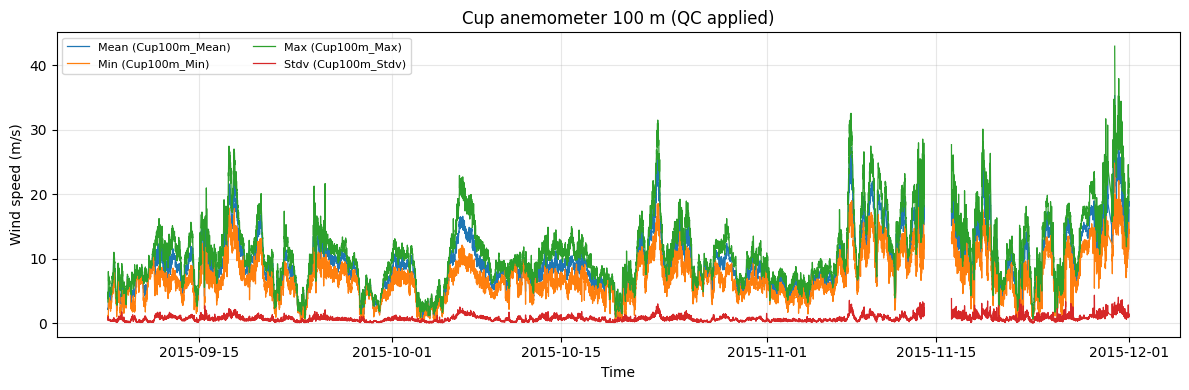

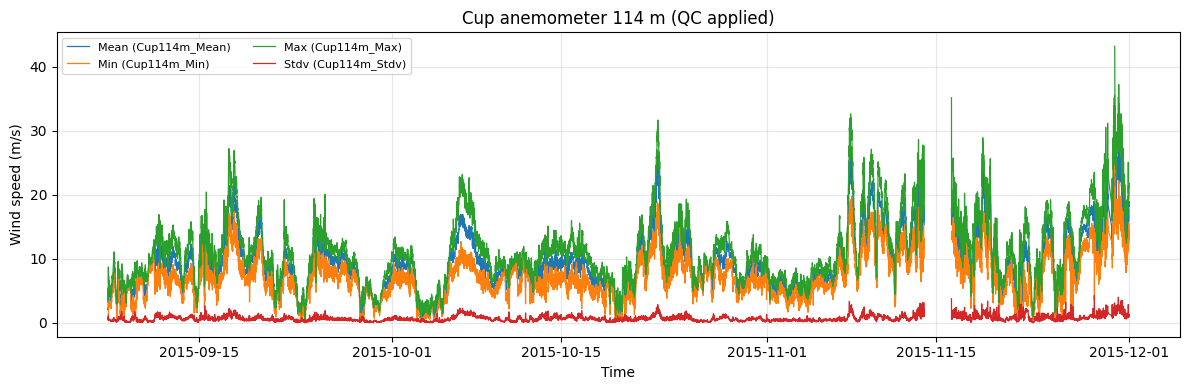

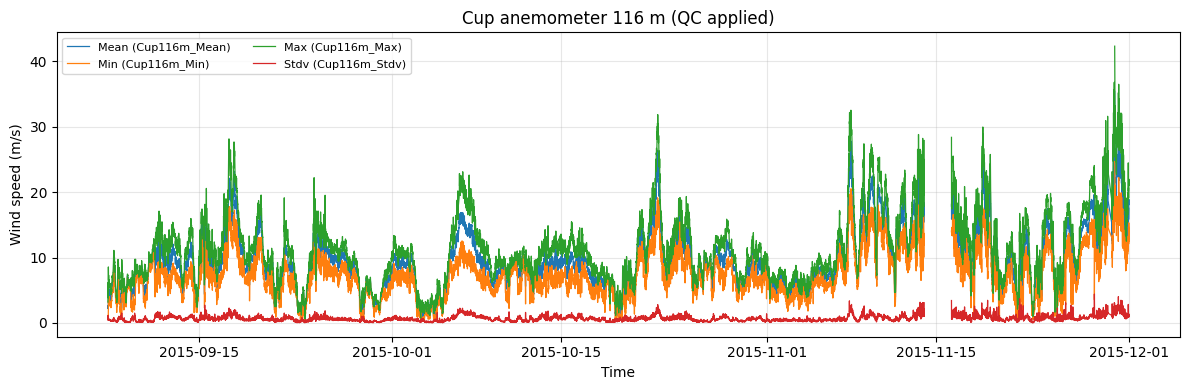

In [22]:
plot_timeseries_group(
    df_qc,
    ["Cup100m_Mean", "Cup100m_Min", "Cup100m_Max", "Cup100m_Stdv"],
    "Cup anemometer 100 m (QC applied)",
    "Wind speed (m/s)",
)

plot_timeseries_group(
    df_qc,
    ["Cup114m_Mean", "Cup114m_Min", "Cup114m_Max", "Cup114m_Stdv"],
    "Cup anemometer 114 m (QC applied)",
    "Wind speed (m/s)",
)

plot_timeseries_group(
    df_qc,
    ["Cup116m_Mean", "Cup116m_Min", "Cup116m_Max", "Cup116m_Stdv"],
    "Cup anemometer 116 m (QC applied)",
    "Wind speed (m/s)",
)

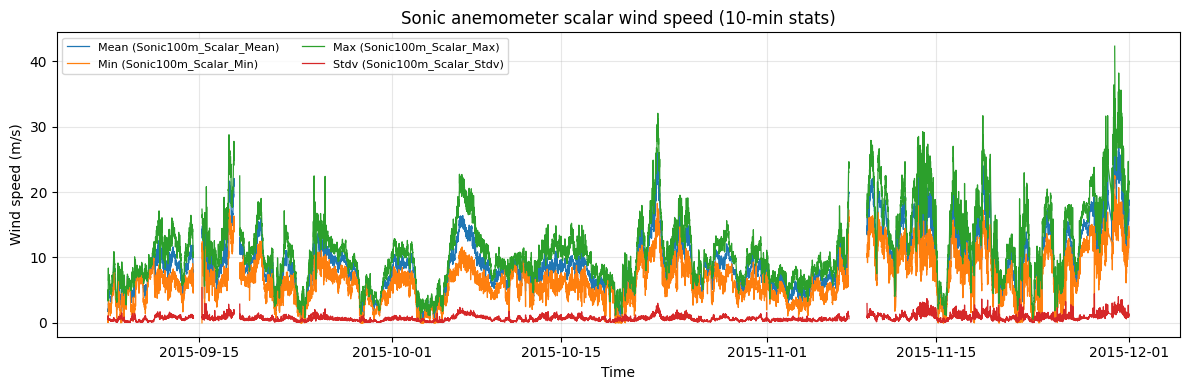

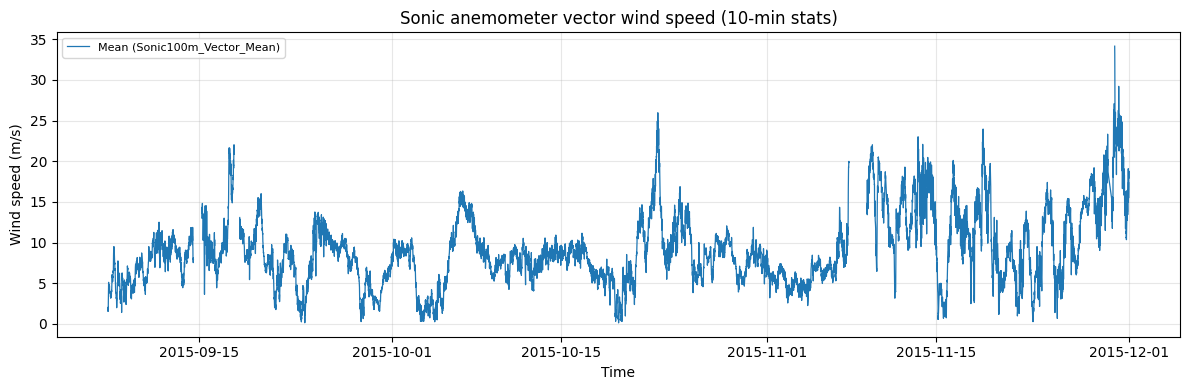

In [20]:
plot_timeseries_group(
    df_qc,
    ["Sonic100m_Scalar_Mean", "Sonic100m_Scalar_Min", "Sonic100m_Scalar_Max", "Sonic100m_Scalar_Stdv"],
    "Sonic anemometer scalar wind speed (10-min stats)",
    "Wind speed (m/s)",
)

plot_timeseries_group(
    df_qc,
    ["Sonic100m_Vector_Mean"],
    "Sonic anemometer vector wind speed (10-min stats)",
    "Wind speed (m/s)",
)

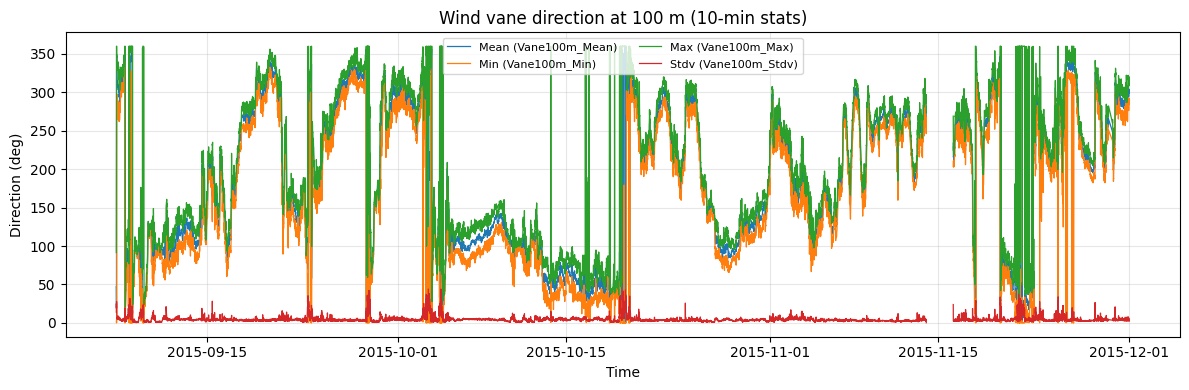

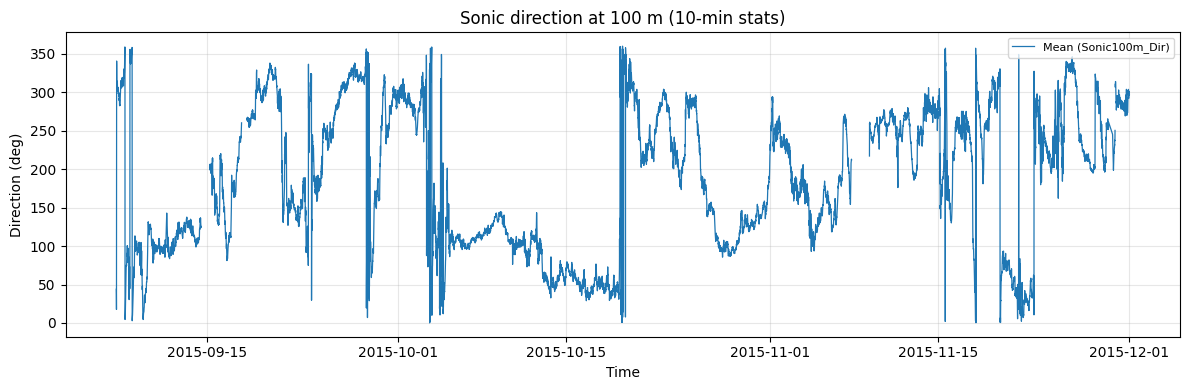

In [21]:
plot_timeseries_group(
    df_qc,
    ["Vane100m_Mean", "Vane100m_Min", "Vane100m_Max", "Vane100m_Stdv"],
    "Wind vane direction at 100 m (10-min stats)",
    "Direction (deg)",
)

plot_timeseries_group(
    df_qc,
    ["Sonic100m_Dir"],
    "Sonic direction at 100 m (10-min stats)",
    "Direction (deg)",
)



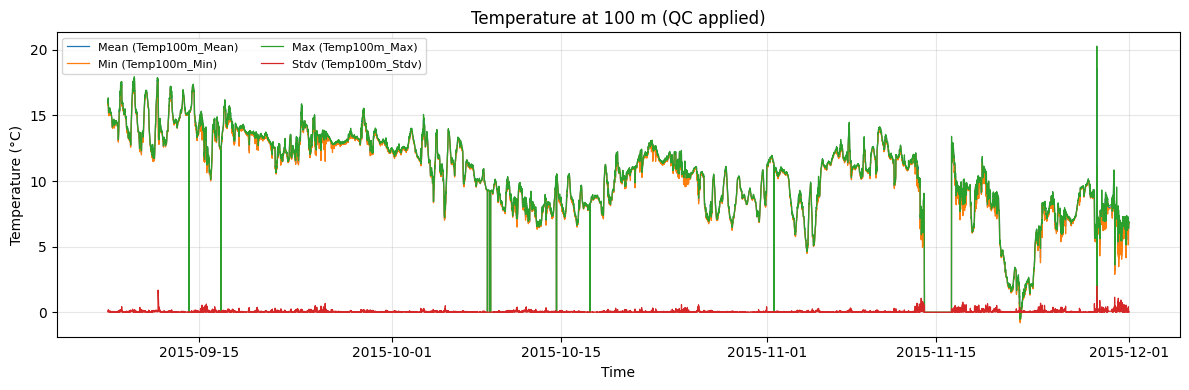

In [32]:
plot_timeseries_group(
    df_qc,
    ["Temp100m_Mean", "Temp100m_Min", "Temp100m_Max", "Temp100m_Stdv"],
    "Temperature at 100 m (QC applied)",
    "Temperature (°C)",
)

In [18]:
df_qc.columns

Index(['name', 'Cup116m_Mean', 'Cup116m_Stdv', 'Cup116m_Min', 'Cup116m_Max',
       'Cup114m_Mean', 'Cup114m_Stdv', 'Cup114m_Min', 'Cup114m_Max',
       'Cup100m_Mean', 'Cup100m_Stdv', 'Cup100m_Min', 'Cup100m_Max',
       'Vane100m_Mean', 'Vane100m_Stdv', 'Vane100m_Min', 'Vane100m_Max',
       'Temp100m_Mean', 'Temp100m_Stdv', 'Temp100m_Min', 'Temp100m_Max',
       'Sonic100m_Scalar_Mean', 'Sonic100m_Scalar_Stdv',
       'Sonic100m_Scalar_Min', 'Sonic100m_Scalar_Max', 'Sonic100m_Dir',
       'Sonic100m_Vector_Mean', 'Spd', 'Spd_stdv', 'Spd_min', 'Spd_max', 'Dir',
       'Dir_stdv', 'W', 'W_stdv', 'Available', 'CNR', 'Broad', 'time'],
      dtype='object')